In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             confusion_matrix, roc_auc_score, roc_curve, r2_score, mean_squared_error)

# For reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("Libraries imported successfully.")

Libraries imported successfully.


In [11]:
# Specific path provided by the user
DATA_PATH = r"U:\Prottoy\CSE422 Lab Project\Loan Approval Dataset.csv"

try:
    df = pd.read_csv(DATA_PATH)
    print("Dataset loaded successfully.")
    print(f"Dataset Shape: {df.shape}")
    display(df.head())
except FileNotFoundError:
    print(f"Error: The file was not found at {DATA_PATH}. Please verify the path.")

Dataset loaded successfully.
Dataset Shape: (45000, 14)


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [12]:
TARGET = "loan_status"

# Separate features and target
X = df.drop(columns=[TARGET])
y = df[TARGET]

# Identify column types
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()

# 80/20 Stratified Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

# Preprocessing Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"Training set size: {X_train_processed.shape[0]}")
print(f"Testing set size: {X_test_processed.shape[0]}")

Training set size: 36000
Testing set size: 9000


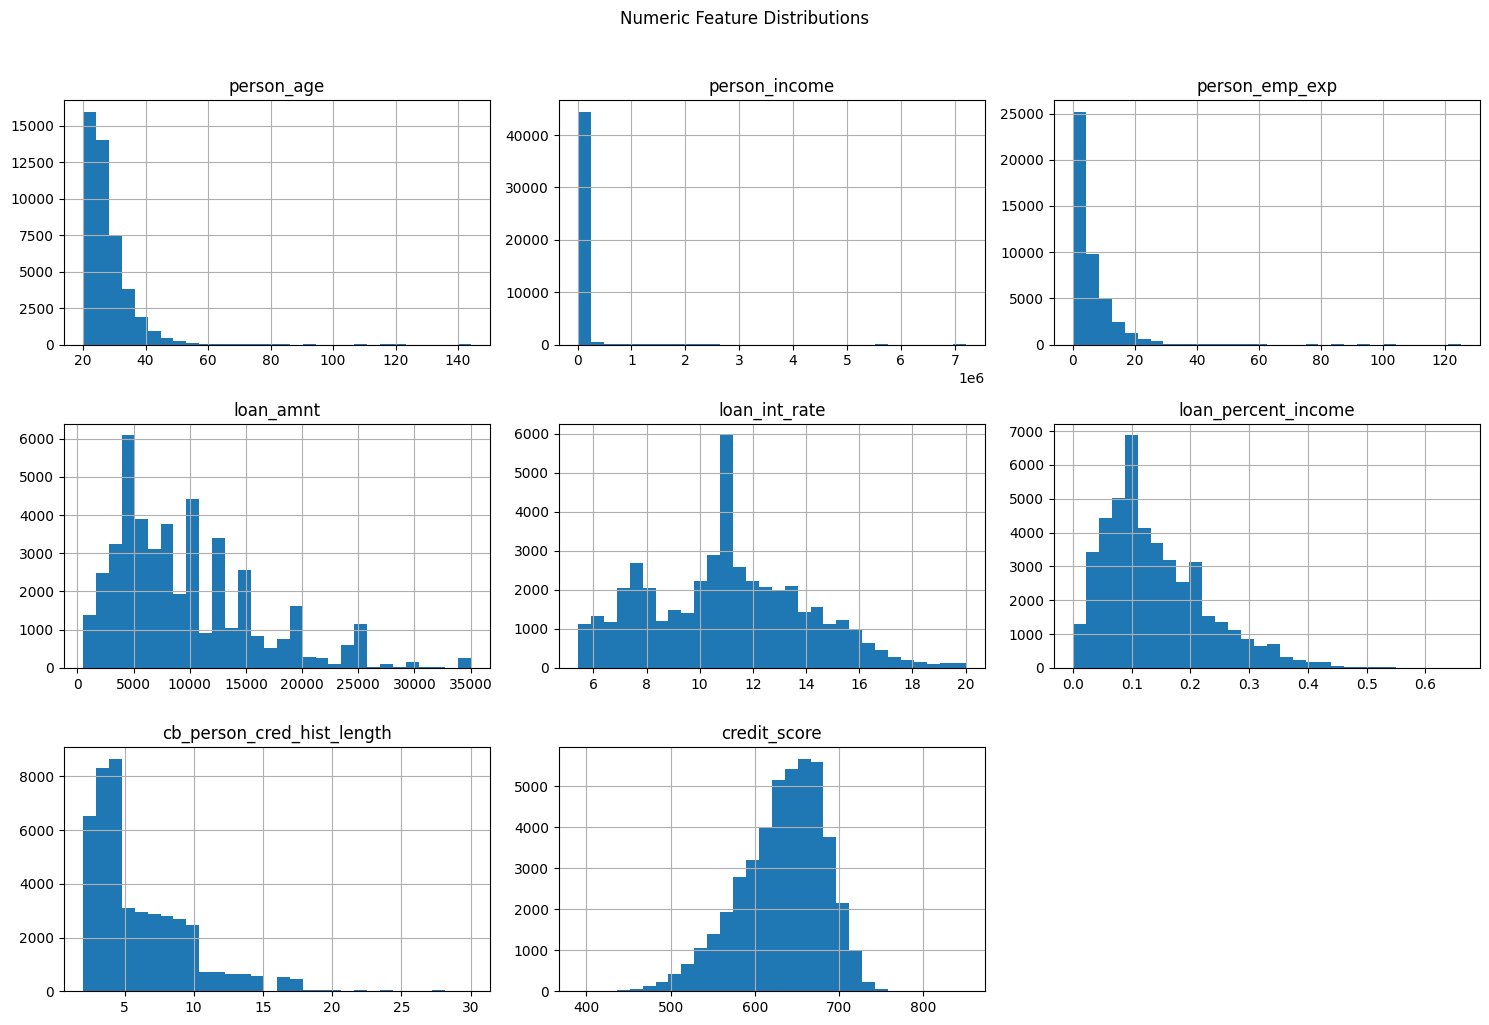

In [13]:
# Histograms for numeric features
df[num_cols].hist(bins=30, figsize=(15, 10))
plt.suptitle("Numeric Feature Distributions", y=1.02)
plt.tight_layout()
plt.show()

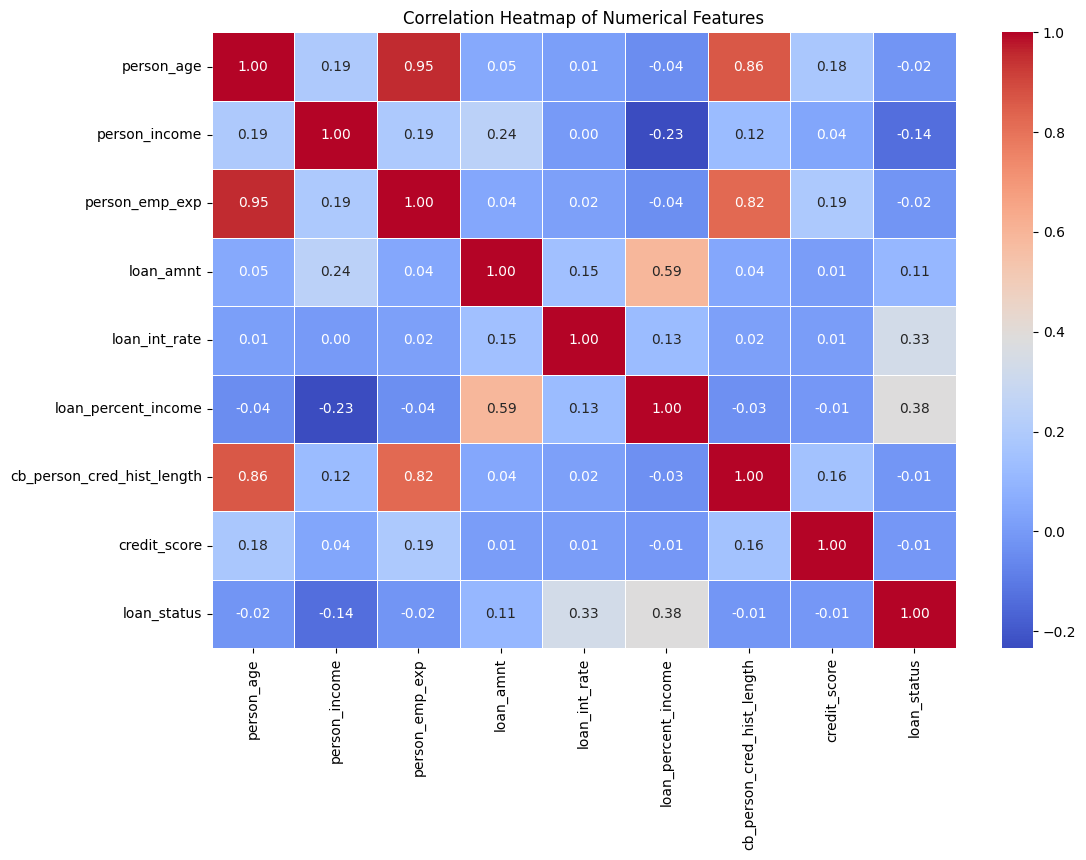

In [14]:
# Correlation Heatmap
plt.figure(figsize=(12, 8))
# Select only numerical columns for correlation
numeric_df = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

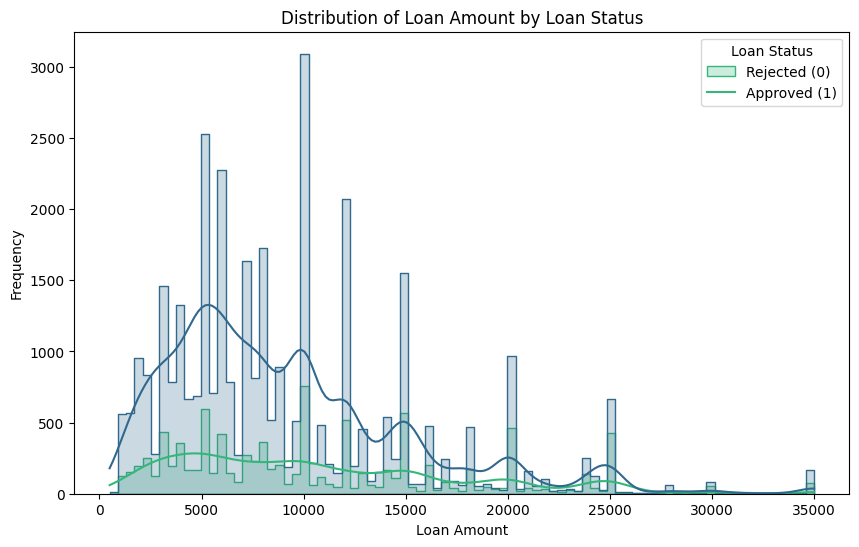

In [15]:
# EDA Chart: Distribution of Loan Amount by Loan Status
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='loan_amnt', hue='loan_status', kde=True, element="step", palette='viridis')

plt.title('Distribution of Loan Amount by Loan Status')
plt.xlabel('Loan Amount')
plt.ylabel('Frequency')
plt.legend(title='Loan Status', labels=['Rejected (0)', 'Approved (1)'])
plt.show()

In [16]:
models = {
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=SEED),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=SEED),
    "Naive Bayes": GaussianNB(),
    "Neural Network": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=SEED)
}

results = []

for name, model in models.items():
    model.fit(X_train_processed, y_train)
    y_pred = model.predict(X_test_processed)
    y_proba = model.predict_proba(X_test_processed)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "AUC": auc,
        "y_pred": y_pred,
        "y_proba": y_proba
    })

# Add Linear Regression (as a separate regression check)
lin_reg = LinearRegression()
lin_reg.fit(X_train_processed, y_train)
lin_pred = lin_reg.predict(X_test_processed)
print(f"\nLinear Regression R2 Score: {r2_score(y_test, lin_pred):.4f}")
print(f"Linear Regression MSE (Loss): {mean_squared_error(y_test, lin_pred):.4f}")


Linear Regression R2 Score: 0.4735
Linear Regression MSE (Loss): 0.0910


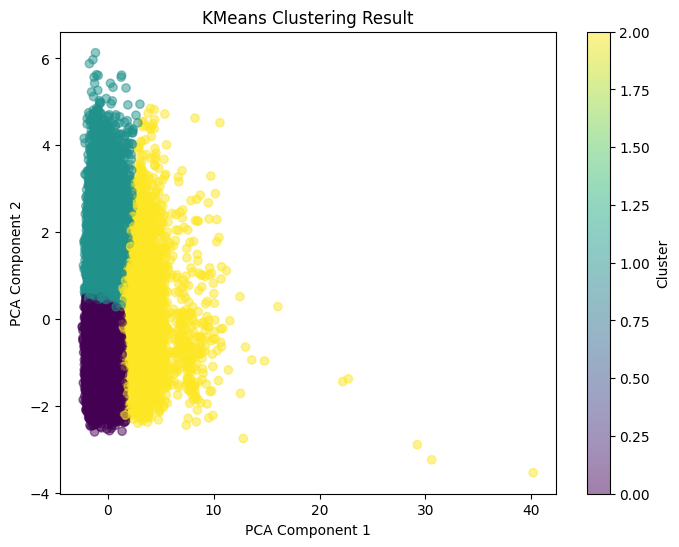

In [17]:
# Applying KMeans (using 3 clusters as identified in the Lab Report)
kmeans = KMeans(n_clusters=3, random_state=SEED, n_init=10)
clusters = kmeans.fit_predict(X_train_processed)

# Visualizing clusters (using first two principal components for 2D plot)
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
reduced_data = pca.fit_transform(X_train_processed)

plt.figure(figsize=(8, 6))
plt.scatter(reduced_data[:, 0], reduced_data[:, 1], c=clusters, cmap='viridis', marker='o', alpha=0.5)
plt.title("KMeans Clustering Result")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(label='Cluster')
plt.show()

C:\Users\Umama Tasnuva Aziz\AppData\Local\Temp\ipykernel_9648\1153013225.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y="Accuracy", data=res_df, palette="viridis")


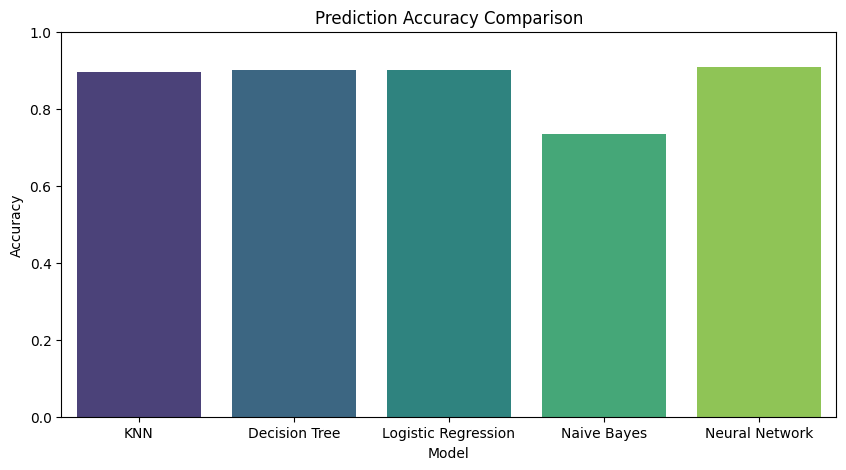

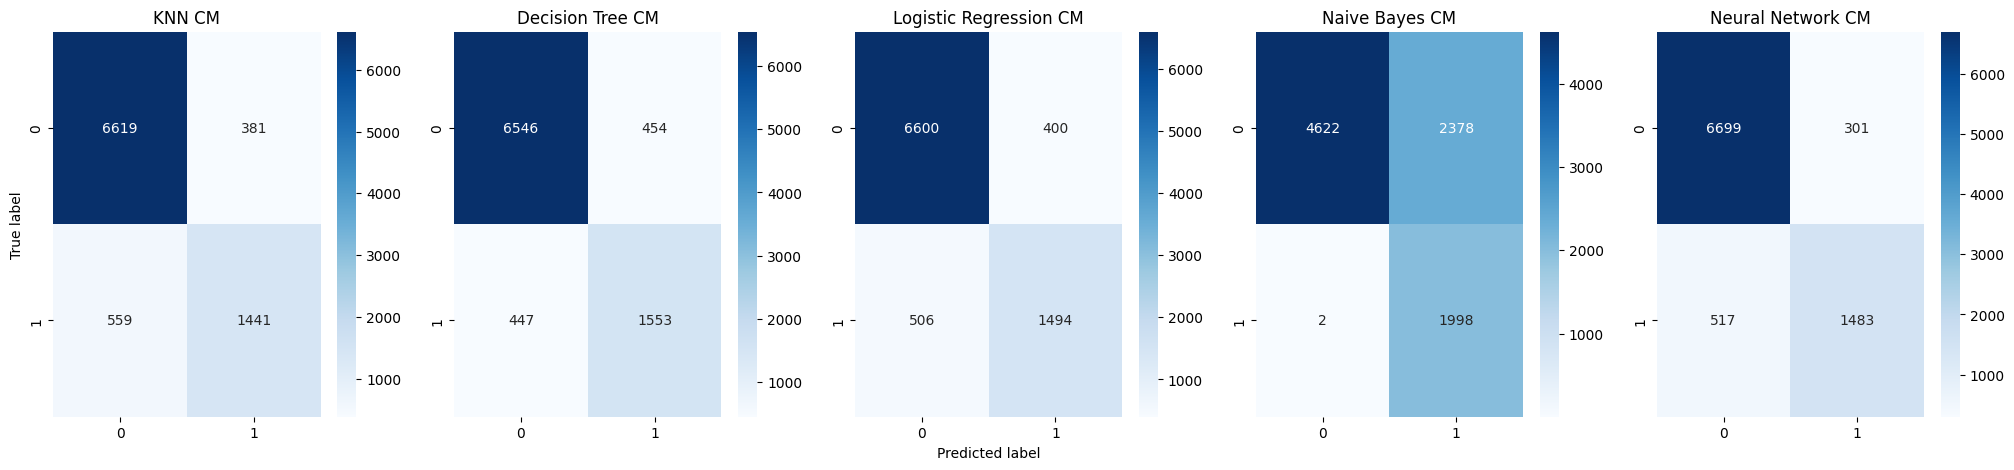

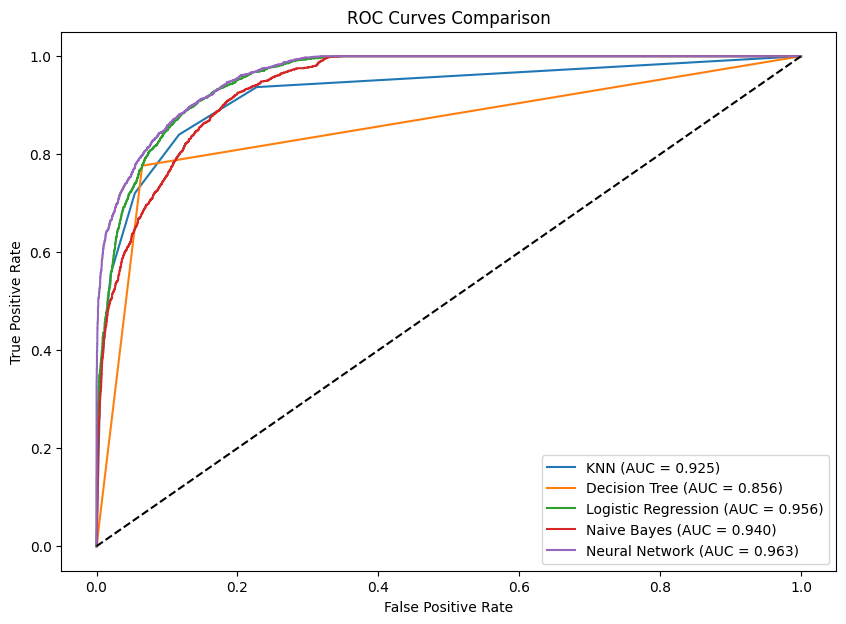

,Model,Accuracy,Precision,Recall,AUC
0,KNN,0.895556,0.790889,0.7205,0.924578
1,Decision Tree,0.899889,0.773792,0.7765,0.855821
2,Logistic Regression,0.899333,0.788807,0.7470,0.956219
3,Naive Bayes,0.735556,0.456581,0.9990,0.939780
4,Neural Network,0.909111,0.831278,0.7415,0.962879


In [18]:
res_df = pd.DataFrame(results)

# 1. Accuracy Bar Chart
plt.figure(figsize=(10, 5))
sns.barplot(x="Model", y="Accuracy", data=res_df, palette="viridis")
plt.title("Prediction Accuracy Comparison")
plt.ylim(0, 1)
plt.show()

# 2. Confusion Matrices for each classification model
fig, axes = plt.subplots(1, 5, figsize=(25, 5))
for i, res in enumerate(results):
    cm = confusion_matrix(y_test, res["y_pred"])
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[i], cmap='Blues')
    axes[i].set_title(f"{res['Model']} CM")
axes[0].set_ylabel("True label")
axes[2].set_xlabel("Predicted label")
plt.show()

# 3. ROC Curves
plt.figure(figsize=(10, 7))
for res in results:
    fpr, tpr, _ = roc_curve(y_test, res["y_proba"])
    plt.plot(fpr, tpr, label=f"{res['Model']} (AUC = {res['AUC']:.3f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend()
plt.show()

# 4. Metric Comparison Table
display(res_df[["Model", "Accuracy", "Precision", "Recall", "AUC"]])